<a href="https://colab.research.google.com/github/thuBv-123/Bai-tap-buoi-2/blob/main/Nha%20dien%20tien%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nhận diện tiền

import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img,img_to_array,to_categorical
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Dropout
from keras.models import Sequential, load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir='/content/drive/MyDrive/MONEY_TRAIN'
val_dir='/content/drive/MyDrive/MONEY_VAL'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)


from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


val_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)
val_generator=val_datagen.flow_from_directory(
    val_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)


model=Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[early_stop]
)

Found 90 images belonging to 9 classes.
Found 45 images belonging to 9 classes.
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 13s/step - accuracy: 0.1384 - loss: 2.3099 - val_accuracy: 0.1333 - val_loss: 2.1906
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 470ms/step - accuracy: 0.1353 - loss: 2.2049 - val_accuracy: 0.0889 - val_loss: 2.1924
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 765ms/step - accuracy: 0.1347 - loss: 2.1764 - val_accuracy: 0.1333 - val_loss: 2.1896
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 0.1423 - loss: 2.1957 - val_accuracy: 0.1111 - val_loss: 2.1788
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 0.1722 - loss: 2.1641 - val_accuracy: 0.2222 - val_loss: 2.1558
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step - accuracy: 0.1965 - loss: 2.1468 - val_accuracy: 0.1111 - val_loss: 2.1216
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step - accuracy: 0.2153 - loss: 2.0933 - val_accuracy: 0.2222 - val_loss: 2.0491
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


Text(0.5, 1.0, 'Tiền này có mệnh giá là :500.000 dong')

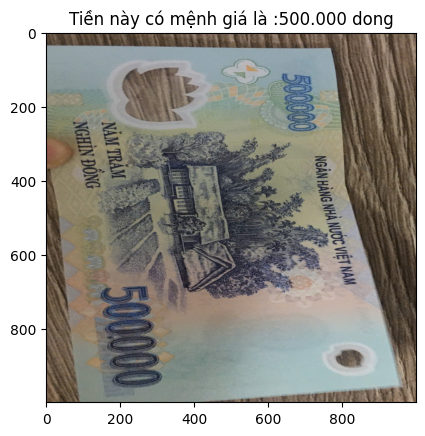

In [ ]:
img = load_img('/content/tien cua AThu.jpg', target_size=(1000, 1000))
plt.imshow(img)
img = img.resize((64, 64))
img_array = img_to_array(img) / 255.0
img_array = img_array.reshape(1, 64, 64, 3)
prediction = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
plt.title(f'Tiền này có mệnh giá là :{predicted_class}')